In [1]:
!pip install torch torchvision torchaudio
!pip install transformers
!pip install timm
!pip install pandas scikit-learn pillow

In [24]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Utility Libraries
import os
import json
import zipfile
from tqdm import tqdm

# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.checkpoint import checkpoint
from torch.utils.data import random_split

# Image Processing
from PIL import Image
from torchvision import transforms, models
import torchvision.transforms as T
from datasets import load_dataset
import timm

# NLP and Transformers
import transformers
from transformers import ViTModel, BertModel, AutoTokenizer, BertTokenizer, AutoModel
from transformers import CLIPProcessor, CLIPModel

# Hide Warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Check if GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    print("GPU is available.")
else:
    print("GPU is not available. Using CPU instead.")

GPU is available.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Setup random Seed
torch.manual_seed(42)

# for GPU
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

# for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [7]:
# Unzip dataset
!cp /content/drive/MyDrive/dataset.zip /content/
with zipfile.ZipFile("/content/dataset.zip", "r") as z:
    files = z.infolist()

    for file in tqdm(files, desc="Extracting dataset"):     # Progress bar
        z.extract(file.filename, path="/content/dataset")

Extracting dataset: 100%|██████████| 1456/1456 [00:01<00:00, 1151.70it/s]


In [16]:
# Load datasets
train_df = pd.read_csv("/content/dataset/dataset/data_train.csv")
val_df = pd.read_csv("/content/dataset/dataset/data_eval.csv")

print(len(train_df))
print(train_df.head())

9974
                                          question        answer   image_id
0                what is the object on the shelves           cup   image100
1                         how man chairs are there             6   image888
2      what is hanged to the right side of the bed       curtain  image1174
3                 how many picture are on the wall             2   image942
4  what is the object on the floor behind the rack  room_divider  image1220


In [17]:
# Convert datasets to dataframe
train_df["image_path"] = "/content/dataset/dataset/images/" + train_df["image_id"] + ".png"
val_df["image_path"] = "/content/dataset/dataset/images/" + val_df["image_id"] + ".png"

train_df.head()

,question,answer,image_id,image_path
0,what is the object on the shelves,cup,image100,/content/dataset/dataset/images/image100.png
1,how man chairs are there,6,image888,/content/dataset/dataset/images/image888.png
2,what is hanged to the right side of the bed,curtain,image1174,/content/dataset/dataset/images/image1174.png
3,how many picture are on the wall,2,image942,/content/dataset/dataset/images/image942.png
4,what is the object on the floor behind the rack,room_divider,image1220,/content/dataset/dataset/images/image1220.png


In [18]:
# Clean train answers
train_df["answers"] = train_df["answer"].apply(lambda x: [a.strip() for a in x.split(",")])

train_exp = train_df.explode("answers")

answer_freq = train_exp["answers"].value_counts()

In [19]:
# Return the most frequent answer from a list
def pick_best_ans(ans_list):
    ans_list = [a.strip() for a in ans_list]
    return max(ans_list, key=lambda x: answer_freq.get(x, 0))

In [20]:
train_df["answer"] = train_df["answers"].apply(pick_best_ans)
train_df = train_df.drop(columns=["answers"])

In [21]:
# Clean validation answers
val_df["answers"] = val_df["answer"].apply(lambda x: [a.strip() for a in x.split(",")])

val_df["answer"] = val_df["answers"].apply(pick_best_ans)

val_df = val_df.drop(columns=["answers"])

In [22]:
# Filter top answers
top_answers = train_df["answer"].value_counts().nlargest(300).index

train_df = train_df[train_df["answer"].isin(top_answers)]
val_df = val_df[val_df["answer"].isin(top_answers)]

In [23]:
# Create a mapping from each answer to a unique index
answer_to_idx = {ans: i for i, ans in enumerate(top_answers)}

train_df["label"] = train_df["answer"].map(answer_to_idx)
val_df["label"] = val_df["answer"].map(answer_to_idx)

In [25]:
# CLIP
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [26]:
# Get feature from images
def encode_image_clip(image_path):
    image = Image.open(image_path).convert("RGB").resize((224,224))
    inputs = processor(images=image, return_tensors="pt")
    outputs = clip_model.vision_model(
        pixel_values=inputs["pixel_values"])

    image_embeding = outputs.pooler_output
    image_embeding = clip_model.visual_projection(image_embeding)

    return image_embeding

In [27]:
# Extract features from questions
def encode_question_clip(q):
    inputs = processor(
        text=[q],
        return_tensors="pt",
        padding=True,
        truncation=True)

    outputs = clip_model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"])

    text_embeding = outputs.pooler_output
    text_embeding = clip_model.text_projection(text_embeding)

    return text_embeding

In [28]:
# Combination between text and images
def fuse_features(q_feat, img_feat):
    mul = q_feat * img_feat
    diff = torch.abs(q_feat - img_feat)
    fused = torch.cat([q_feat, img_feat, mul, diff], dim=1)

    return fused

In [29]:
# Custom Dataset class for VQA
class VQADataset(Dataset):

    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)          # Return total number of samples

    def __getitem__(self, idx):

        question = self.df.iloc[idx]["question"]
        image_path = self.df.iloc[idx]["image_path"]
        label = self.df.iloc[idx]["label"]

        # Encode question and image using CLIP
        q = encode_question_clip(question)
        img = encode_image_clip(image_path)

        x = fuse_features(q,img).squeeze(0)          # Fuse text and image features into a single representation
        y = torch.tensor(label, dtype=torch.long)          # Convert label to tensor

        return x, y

In [30]:
# Freeze most CLIP parameters and only fine-tune projection layers
for name, param in clip_model.named_parameters():

    if "visual_projection" in name or "text_projection" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

In [31]:
# Generate dataloader
train_dataset = VQADataset(train_df)
val_dataset = VQADataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

In [32]:
# Create Classifier
model = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(answer_to_idx)))

model = model.to(device)

In [33]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)     # Loss function
optimizer = torch.optim.Adam(
    list(model.parameters()) + list(filter(lambda p: p.requires_grad, clip_model.parameters())),
    lr=1e-5
)

In [34]:
model.train()

Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=512, out_features=300, bias=True)
)

In [35]:
# Training and validation loop for the model
epochs = 20
for epoch in range(epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch}")

    for x, y in loop:
        x = x.to(device)
        y = y.to(device)
        y_pred = model(x)

        loss = criterion(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        pred = torch.argmax(y_pred, dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
        loop.set_postfix(loss=loss.item())

    train_acc = correct / total


    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc="Validation"):
            x = x.to(device)
            y = y.to(device)
            y_pred = model(x)
            loss = criterion(y_pred, y)
            val_loss += loss.item()
            pred = torch.argmax(y_pred, dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    print("Epoch:", epoch)
    print("Train Loss:", train_loss/len(train_loader))
    print("Val Loss:", val_loss/len(val_loader))
    print("Train Acc:", train_acc)
    print("Val Acc:", val_acc)
    print()

Validation: 100%|██████████| 149/149 [03:31<00:00,  1.42s/it]


Epoch: 0
Train Loss: 5.3027764627528935
Val Loss: 4.832833546120049
Train Acc: 0.041971743838300504
Val Acc: 0.07979840403191936



Validation: 100%|██████████| 149/149 [03:28<00:00,  1.40s/it]


Epoch: 1
Train Loss: 4.840032656071017
Val Loss: 4.572052209969335
Train Acc: 0.09178096318449006
Val Acc: 0.1608567828643427



Validation: 100%|██████████| 149/149 [03:27<00:00,  1.40s/it]


...

Epoch: 17
Train Loss: 3.552196981486614
Val Loss: 3.5118240302041075
Train Acc: 0.28730535217077446
Val Acc: 0.29357412851742964



Validation: 100%|██████████| 149/149 [03:28<00:00,  1.40s/it]


Epoch: 18
Train Loss: 3.524640279311128
Val Loss: 3.4960257511010906
Train Acc: 0.29308033412395584
Val Acc: 0.2855942881142377



Validation: 100%|██████████| 149/149 [03:28<00:00,  1.40s/it]

Epoch: 19
Train Loss: 3.497363617235589
Val Loss: 3.4789691163389476
Train Acc: 0.2976178199443127
Val Acc: 0.29315413691726167



In [37]:
epochs = list(range(20))

train_loss = [
    5.30,4.84,4.59,4.36,4.21,4.11,4.03,3.96,3.89,3.85,
    3.80,3.75,3.71,3.68,3.63,3.60,3.58,3.55,3.52,3.49
]

val_loss = [
    4.83,4.57,4.33,4.14,4.03,3.93,3.87,3.80,3.76,3.72,
    3.68,3.65,3.62,3.59,3.57,3.55,3.53,3.51,3.49,3.47
]

train_acc = [
    0.04,0.09,0.14,0.17,0.18,0.19,0.21,0.21,0.23,0.23,
    0.24,0.24,0.26,0.27,0.27,0.27,0.27,0.28,0.29,0.29
]

val_acc = [
    0.07,0.16,0.18,0.21,0.21,0.23,0.23,0.25,0.25,0.26,
    0.26,0.26,0.27,0.27,0.27,0.28,0.28,0.29,0.28,0.29
]

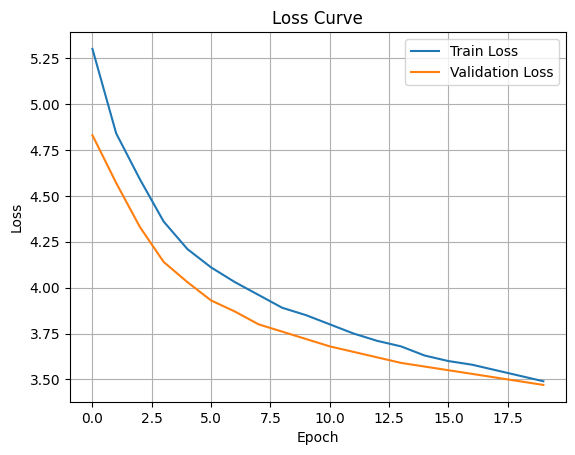

In [42]:
# Plot Loss
plt.figure()

plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()
plt.grid()

plt.show()

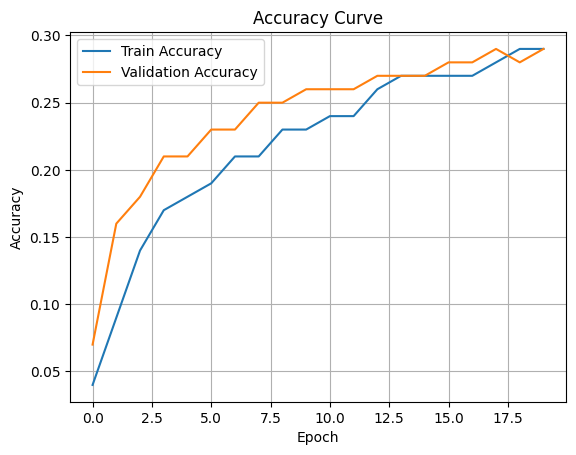

In [41]:
# Plot accuracy
plt.figure()

plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()
plt.grid()

plt.show()

In [80]:
# Save best model
torch.save(model.state_dict(), "best_model.pt")
print(os.path.exists("best_model.pt"))

!cp best_model.pt /content/drive/MyDrive/

True


**Test Model**

In [81]:
# Load the best model
model.load_state_dict(torch.load("best_model.pt", map_location=device))

model.to(device)
model.eval()

Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=512, out_features=300, bias=True)
)

In [115]:
# Define test function
def show_prediction(image_path, question):
    model.eval()
    clip_model.eval()

    # Text
    inputs_q = processor(
        text=[question],
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    inputs_q = {k: v.to(device) for k, v in inputs_q.items()}

    with torch.no_grad():
        text_outputs = clip_model.text_model(
            input_ids=inputs_q["input_ids"],
            attention_mask=inputs_q["attention_mask"]
        )
        q_feat = text_outputs.pooler_output
        q_feat = clip_model.text_projection(q_feat)

    # Image
    image = Image.open(image_path).convert("RGB")

    inputs_img = processor(images=[image], return_tensors="pt")
    inputs_img = {k: v.to(device) for k, v in inputs_img.items()}

    with torch.no_grad():
        vision_outputs = clip_model.vision_model(
            pixel_values=inputs_img["pixel_values"]
        )
        img_feat = vision_outputs.pooler_output
        img_feat = clip_model.visual_projection(img_feat)

    # Fuse
    x = fuse_features(q_feat, img_feat)

    # Predict
    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)

        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()

    answer = idx_to_answer[pred]

    # Top 3 answers
    topk = torch.topk(probs, 3)
    top_answers = [idx_to_answer[i.item()] for i in topk.indices[0]]
    top_scores = [round(v.item(), 3) for v in topk.values[0]]

    # Show image
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Q: {question}\n"
        f"A: {answer} ({confidence:.2f})\n"
        f"Top3: {list(zip(top_answers, top_scores))}"
    )

    plt.show()
    return answer, confidence

In [110]:
# Test Model
def test_model(val_df, n=10):
    correct = 0

    for i in range(n):
        row = val_df.iloc[i]
        image_path = row["image_path"]
        question = row["question"]
        gt = row["answer"]
        pred, conf = show_prediction(image_path, question)
        print(f"GT: {gt}")

        if pred == gt:
            print("✅ Correct")
            correct += 1
        else:
            print("❌ Wrong")

        print("="*50)

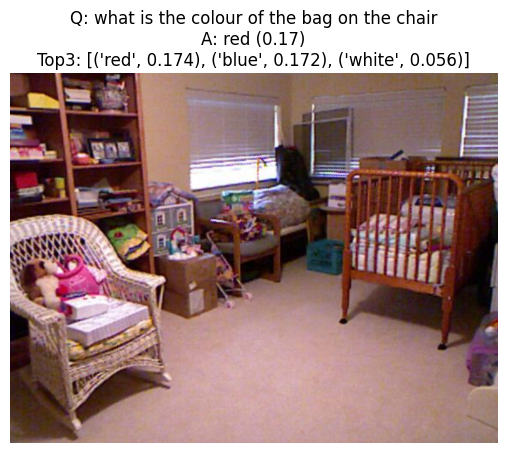

GT: pink
❌ Wrong


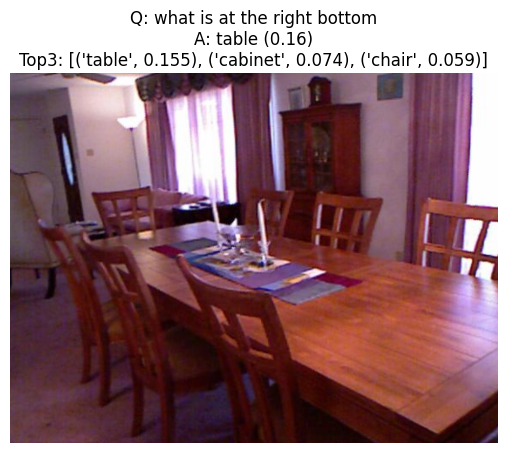

GT: table
✅ Correct


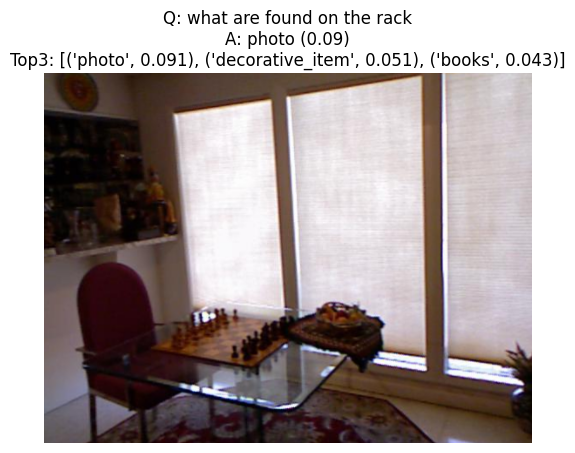

GT: toy
❌ Wrong


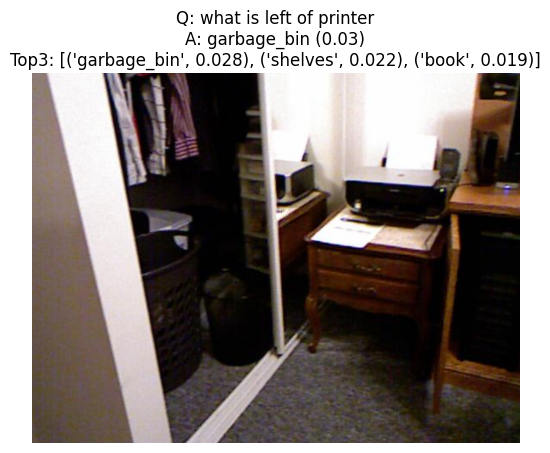

GT: mirror
❌ Wrong


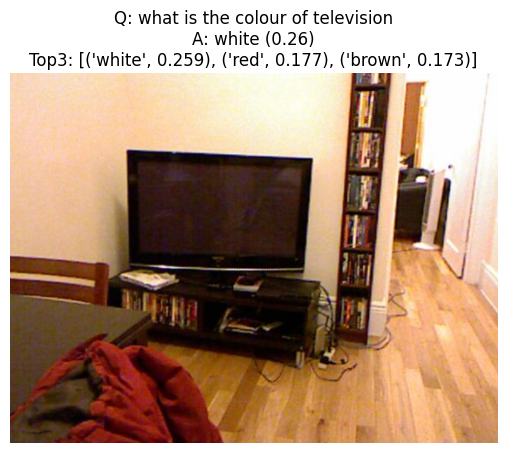

GT: black
❌ Wrong


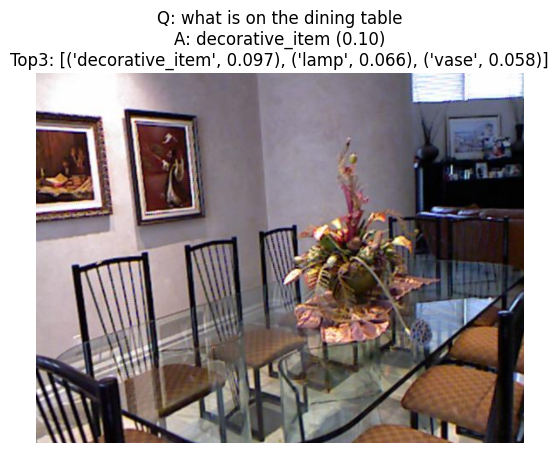

GT: ornamental_plant
❌ Wrong


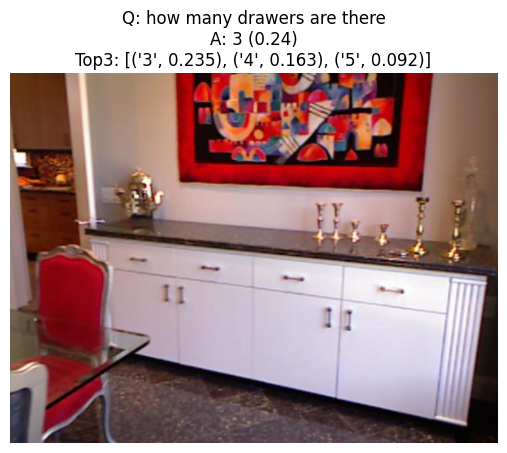

GT: 4
❌ Wrong


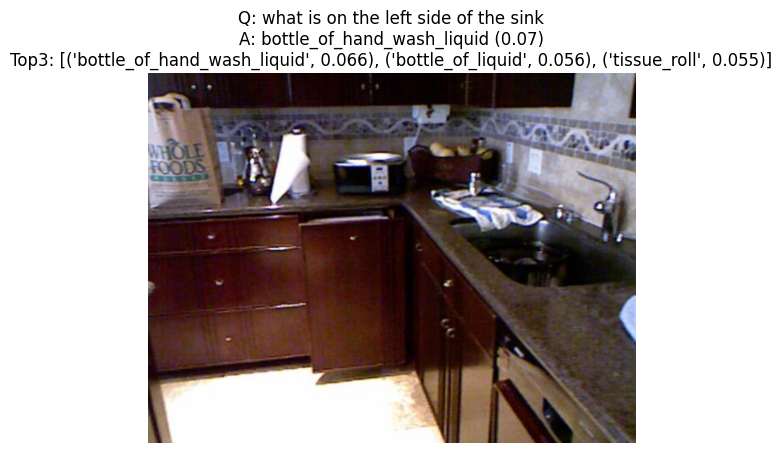

GT: towel
❌ Wrong


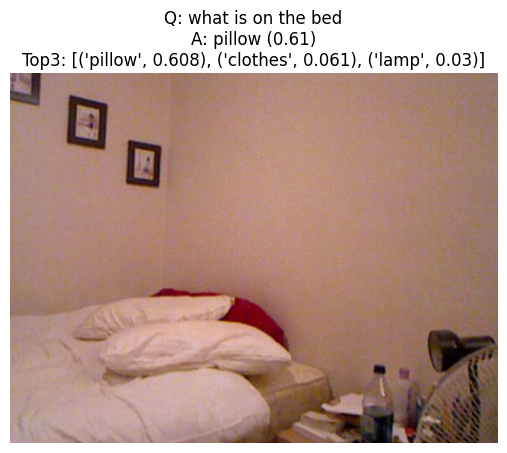

GT: pillow
✅ Correct


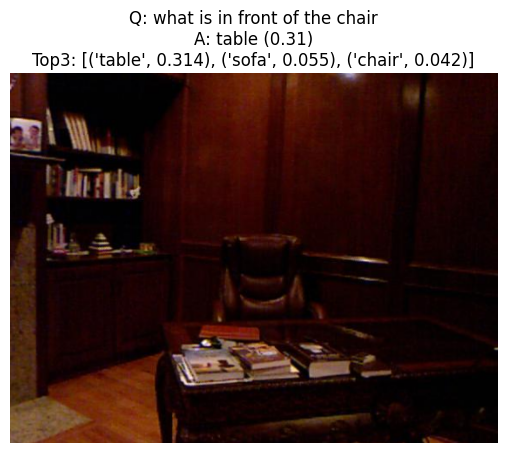

GT: table
✅ Correct


In [111]:
test_model(val_df, n=10)

###**Video**

In [116]:
torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pt")
torch.save({
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
}, "/content/drive/MyDrive/full_checkpoint.pt")

In [117]:
import pickle
with open("/content/drive/MyDrive/answer_to_idx.pkl", "wb") as f:
    pickle.dump(answer_to_idx, f)